In [ ]:
!pip install gdown

In [ ]:
!gdown --fuzzy "https://drive.google.com/file/d/1219EeGE1XTJVXYaulynJSa3BXGsbNCLx/view?usp=sharing"

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=432786cf-5ba7-4c25-9ace-ec6101894ce4
To: /content/Archive.zip
100% 1.23G/1.23G [00:16<00:00, 73.3MB/s]


In [ ]:
!ls -lh

total 1.2G
-rw-r--r-- 1 root root 1.2G Jan  8  2024 Archive.zip
drwxr-xr-x 1 root root 4.0K Mar 30 13:29 sample_data


In [ ]:
!unzip Archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/PNEUMONIA/person1381_virus_2375.jpeg  
  inflating: train/PNEUMONIA/person1608_bacteria_4235.jpeg  
  inflating: train/PNEUMONIA/person445_virus_916.jpeg  
  inflating: train/PNEUMONIA/person302_bacteria_1430.jpeg  
  inflating: train/PNEUMONIA/person1188_bacteria_3137.jpeg  
  inflating: train/PNEUMONIA/person353_virus_728.jpeg  
  inflating: train/PNEUMONIA/person348_bacteria_1602.jpeg  
  inflating: train/PNEUMONIA/person1272_bacteria_3232.jpeg  
  inflating: train/PNEUMONIA/person1294_virus_2222.jpeg  
  inflating: train/PNEUMONIA/person3_bacteria_12.jpeg  
  inflating: train/PNEUMONIA/person124_virus_234.jpeg  
  inflating: train/PNEUMONIA/person378_virus_761.jpeg  
  inflating: train/PNEUMONIA/person1478_bacteria_3848.jpeg  
  inflating: train/PNEUMONIA/person1446_bacteria_3740.jpeg  
  inflating: train/PNEUMONIA/person23_bacteria_91.jpeg  
  inflating: train/PNEUMONIA/person294_bacteria_1381.jpeg  
  inflating

In [ ]:
import os
os.listdir()

['.config', 'Archive.zip', 'train', 'test', '__MACOSX', 'val', 'sample_data']

In [ ]:
import os
os.listdir("/content")

['.config', 'Archive.zip', 'train', 'test', '__MACOSX', 'val', 'sample_data']

In [ ]:
for root, dirs, files in os.walk("/content"):
    print(root)

/content
/content/.config
/content/.config/logs
/content/.config/logs/2026.03.30
/content/.config/configurations
/content/train
/content/train/PNEUMONIA
/content/train/NORMAL
/content/test
/content/test/PNEUMONIA
/content/test/NORMAL
/content/__MACOSX
/content/__MACOSX/train
/content/__MACOSX/test
/content/val
/content/val/PNEUMONIA
/content/val/NORMAL
/content/sample_data


In [ ]:
print(train_path)
print(val_path)
print(test_path)


NameError: name 'train_path' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

In [ ]:
!pip install gdown
!gdown --fuzzy "https://drive.google.com/file/d/1219EeGE1XTJVXYaulynJSa3BXGsbNCLx/view?usp=sharing"
!unzip Archive.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/PNEUMONIA/person1935_bacteria_4848.jpeg  
  inflating: train/PNEUMONIA/person1593_virus_2767.jpeg  
  inflating: train/PNEUMONIA/person1304_bacteria_3269.jpeg  
  inflating: train/PNEUMONIA/person1381_virus_2375.jpeg  
  inflating: train/PNEUMONIA/person1608_bacteria_4235.jpeg  
  inflating: train/PNEUMONIA/person445_virus_916.jpeg  
  inflating: train/PNEUMONIA/person302_bacteria_1430.jpeg  
  inflating: train/PNEUMONIA/person1188_bacteria_3137.jpeg  
  inflating: train/PNEUMONIA/person353_virus_728.jpeg  
  inflating: train/PNEUMONIA/person348_bacteria_1602.jpeg  
  inflating: train/PNEUMONIA/person1272_bacteria_3232.jpeg  
  inflating: train/PNEUMONIA/person1294_virus_2222.jpeg  
  inflating: train/PNEUMONIA/person3_bacteria_12.jpeg  
  inflating: train/PNEUMONIA/person124_virus_234.jpeg  
  inflating: train/PNEUMONIA/person378_virus_761.jpeg  
  inflating: train/PNEUMONIA/person1478_bacteria_3848.jpeg  
  inflati

In [ ]:
train_path = "/content/train"
val_path = "/content/val"
test_path = "/content/test"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9843 - loss: 0.0440 - val_accuracy: 1.0000 - val_loss: 0.0272
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9873 - loss: 0.0388 - val_accuracy: 0.8750 - val_loss: 0.3611
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 253s 2s/step - accuracy: 0.9902 - loss: 0.0265 - val_accuracy: 0.8750 - val_loss: 0.2384
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 252s 2s/step - accuracy: 0.9902 - loss: 0.0270 - val_accuracy: 0.9375 - val_loss: 0.1349
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.9919 - loss: 0.0190 - val_accuracy: 0.9375 - val_loss: 0.1196


In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 633ms/step - accuracy: 0.7580 - loss: 2.1574
Test Accuracy: 0.7580128312110901


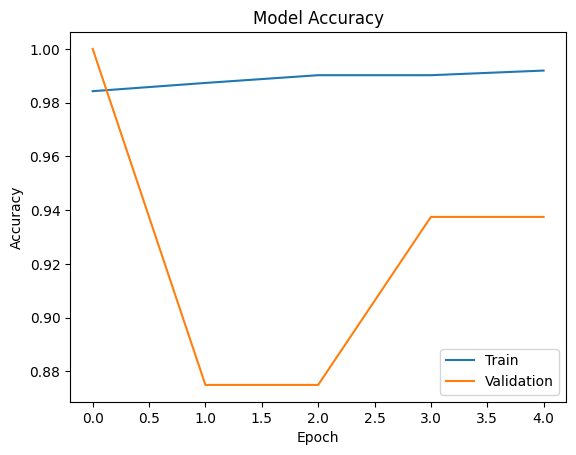

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()

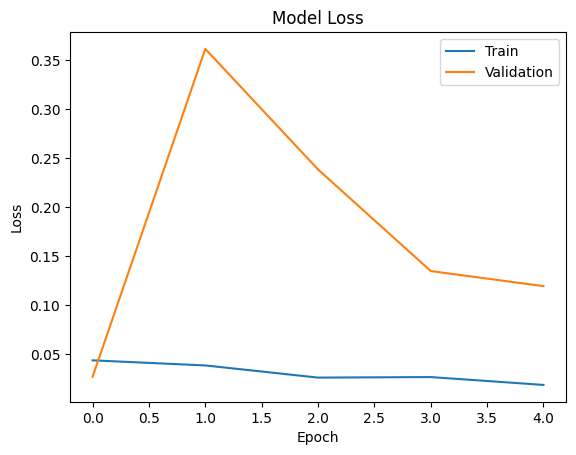

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])
plt.show()